# detmet Library Tutorial

This beginner-friendly Jupyter notebook demonstrates the usage of the `detmet` library for object detection metrics computation using COCO JSON files.

We cover high-level batch processing, fixed-threshold metrics, Ultralytics-style confidence-swept metrics, per-class metrics, low-level single-image processing, PR curves, confusion matrix, and a summary table.

**Prerequisites:**
- Install `detmet`, `pandas`, `numpy`, `matplotlib`.
- Sample files: `../tests/jsons/simple/gt_coco.json`, `../tests/jsons/simple/predictions_coco.json`.

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from detmet import DetectionMetricsManager, DetectionMetrics

In [2]:
def load_coco_jsons(gt_path, pred_path):
    with open(gt_path, 'r') as f:
        gt_coco = json.load(f)
    with open(pred_path, 'r') as f:
        pred_coco = json.load(f)
    return gt_coco, pred_coco


def extract_image_data(gt_coco, pred_coco, image_index=0):
    # Support both COCO-style dicts and plain lists for predictions
    if isinstance(gt_coco, dict):
        anns_gt = gt_coco.get('annotations', [])
    elif isinstance(gt_coco, list):
        anns_gt = gt_coco
    else:
        anns_gt = []

    if isinstance(pred_coco, dict):
        anns_pred = pred_coco.get('annotations', [])
    elif isinstance(pred_coco, list):
        anns_pred = pred_coco
    else:
        anns_pred = []

    image_ids = sorted({ann['image_id'] for ann in anns_gt})
    if not image_ids:
        return None, [], [], np.empty((0,4), dtype=np.float32), np.array([], dtype=np.int64), np.empty((0,4), dtype=np.float32), np.array([], dtype=np.float32), np.array([], dtype=np.int64), 1
    image_id = image_ids[image_index] if image_index < len(image_ids) else image_ids[0]
    gt_anns = [ann for ann in anns_gt if ann['image_id'] == image_id]
    pred_anns = [ann for ann in anns_pred if ann.get('image_id') == image_id]
    gt_boxes = np.array([ann['bbox'] for ann in gt_anns], dtype=np.float32) if gt_anns else np.empty((0,4), dtype=np.float32)
    gt_labels = np.array([ann['category_id'] for ann in gt_anns], dtype=np.int64) if gt_anns else np.array([], dtype=np.int64)
    pred_boxes = np.array([ann['bbox'] for ann in pred_anns], dtype=np.float32) if pred_anns else np.empty((0,4), dtype=np.float32)
    pred_scores = np.array([ann.get('score', 1.0) for ann in pred_anns], dtype=np.float32) if pred_anns else np.array([], dtype=np.float32)
    pred_labels = np.array([ann['category_id'] for ann in pred_anns], dtype=np.int64) if pred_anns else np.array([], dtype=np.int64)
    all_labels = np.hstack([gt_labels, pred_labels]) if (gt_labels.size + pred_labels.size) > 0 else np.array([0], dtype=np.int64)
    num_classes = int(np.max(all_labels)) + 1 if all_labels.size > 0 else 1
    return image_id, gt_anns, pred_anns, gt_boxes, gt_labels, pred_boxes, pred_scores, pred_labels, num_classes


def load_and_extract(gt_path, pred_path, image_index=0):
    gt_coco, pred_coco = load_coco_jsons(gt_path, pred_path)
    return extract_image_data(gt_coco, pred_coco, image_index)

## 1. High-level Usage: DetectionMetricsManager

Load COCO-format ground truth and predictions JSON files and compute metrics in one go.

In [3]:
gt_path = "../tests/jsons/real_case/_annotations.coco.json"
pred_path = "../tests/jsons/real_case/tood_predicts_bbox.bbox.json"

dmm = DetectionMetricsManager(
    groundtruth_json_path=gt_path,
    prediction_json_path=pred_path
)
res = dmm.calculate_metrics(iou_thr=0.5, conf_thr=0.0, exclude_classes=[0])
metrics = res.metrics

## 2. Inspect Individual Metrics

Access the library's fixed-threshold precision, recall, and F1, plus COCO mAP, mAP50, and mAP75. Ultralytics-style confidence-swept metrics are shown in the next section.

In [4]:
print("Overall Metrics:")
global_metrics = metrics.get('global', {})
print(f"Precision: {global_metrics.get('precision', 0):.4f}")
print(f"Recall: {global_metrics.get('recall', 0):.4f}")
print(f"F1: {global_metrics.get('f1', 0):.4f}")
print(f"Support: {global_metrics.get('support', 0)}")
print(f"mAP: {global_metrics.get('mAP', 0):.4f}")
print(f"mAP50: {global_metrics.get('mAP50', 0):.4f}")
print(f"mAP75: {global_metrics.get('mAP75', 0):.4f}")

Overall Metrics:
Precision: 0.4058
Recall: 0.9924
F1: 0.5761
Support: 2228
mAP: 0.8888
mAP50: 0.9709
mAP75: 0.9584


## 3. Ultralytics-Style Metrics

`metrics['ultralytics']` reports precision, recall, and F1 at the best confidence threshold from the F1 curve, plus AP50 and AP50-95 computed from confidence-sorted detections. The original `metrics['global']` values above remain fixed-threshold metrics.

In [5]:
ultra = metrics.get('ultralytics', {})
ultra_global = ultra.get('global', {})

print("Ultralytics-Style Global Metrics:")
if ultra_global:
    print(f"Precision: {ultra_global.get('precision', 0):.4f}")
    print(f"Recall: {ultra_global.get('recall', 0):.4f}")
    print(f"F1: {ultra_global.get('f1', 0):.4f}")
    print(f"Best confidence: {ultra_global.get('best_conf', 0):.4f}")
    print(f"Support: {ultra_global.get('support', 0)}")
    print(f"mAP50: {ultra_global.get('mAP50', 0):.4f}")
    print(f"mAP50-95: {ultra_global.get('mAP50-95', 0):.4f}")
else:
    print("Ultralytics-style metrics are unavailable. Recompute with PR data enabled.")

Ultralytics-Style Global Metrics:
Precision: 0.9410
Recall: 0.8986
F1: 0.9153
Best confidence: 0.4915
Support: 2228
mAP50: 0.9732
mAP50-95: 0.9010


### Ultralytics Per-Class Table

Per-class values use the same best confidence point as the global Ultralytics-style result.

In [6]:
ultra_per_class = ultra.get('per_class', {})

if ultra_per_class:
    ultra_df = pd.DataFrame.from_dict(ultra_per_class, orient='index')
    ultra_cols = ['precision', 'recall', 'f1', 'best_conf', 'support', 'AP50', 'AP50-95']
    display(ultra_df[ultra_cols].round(4))
else:
    print("No Ultralytics-style per-class metrics available.")

,precision,recall,f1,best_conf,support,AP50,AP50-95
Ascaris lumbricoides,0.9515,0.7583,0.8440,0.4915,207,0.9374,0.8961
Capillaria philippinensis,0.8713,0.8867,0.8789,0.4915,203,0.9566,0.8320
Enterobius vermicularis,0.9889,0.8890,0.9363,0.4915,200,0.9709,0.8679
Fasciolopsis buski,0.9821,0.9698,0.9759,0.4915,199,0.9899,0.9284
Hookworm egg,0.9889,0.9951,0.9920,0.4915,204,0.9949,0.9083
Hymenolepis diminuta,0.7984,1.0000,0.8879,0.4915,200,0.9938,0.9743
Hymenolepis nana,0.8871,0.8317,0.8585,0.4915,202,0.9416,0.8540
Opisthorchis viverrine,0.9944,0.9300,0.9611,0.4915,200,0.9841,0.8625
Paragonimus spp,0.8880,0.9474,0.9167,0.4915,209,0.9706,0.9306
Taenia spp egg,1.0000,0.9429,0.9706,0.4915,204,0.9947,0.9681


### Ultralytics Confidence Curves

These curves show the mean precision, recall, and F1 over classes as the confidence threshold changes.

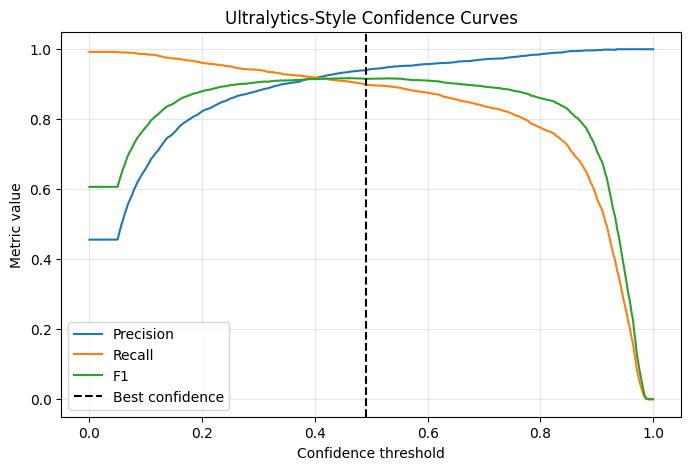

In [7]:
curves = ultra.get('curves', {})
x = curves.get('x')
precision_curve = curves.get('precision')
recall_curve = curves.get('recall')
f1_curve = curves.get('f1')

if x is not None and precision_curve is not None and len(precision_curve):
    plt.figure(figsize=(8, 5))
    plt.plot(x, precision_curve.mean(axis=0), label='Precision')
    plt.plot(x, recall_curve.mean(axis=0), label='Recall')
    plt.plot(x, f1_curve.mean(axis=0), label='F1')
    plt.axvline(ultra_global.get('best_conf', 0), color='black', linestyle='--', label='Best confidence')
    plt.xlabel('Confidence threshold')
    plt.ylabel('Metric value')
    plt.title('Ultralytics-Style Confidence Curves')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()
else:
    print("No Ultralytics-style confidence curves available.")

## 4. Per-Class Metrics

Inspect the fixed-threshold metrics for each class.

In [8]:
print("\nPer-Class Metrics:")
for class_name, class_metrics in metrics.items():
    if class_name in ('global', 'ultralytics', 'pr_curves', 'confusion_matrix', 'confusion_matrix_multiclass'):
        continue
    print(f"Class {class_name}:")
    print(f"  Precision: {class_metrics.get('precision', 0):.4f}")
    print(f"  Recall: {class_metrics.get('recall', 0):.4f}")
    print(f"  F1: {class_metrics.get('f1', 0):.4f}")
    print(f"  mAP: {class_metrics.get('ap', 0):.4f}")


Per-Class Metrics:
Class Ascaris lumbricoides:
  Precision: 0.2951
  Recall: 0.9952
  F1: 0.4552
  mAP: 0.8884
Class Capillaria philippinensis:
  Precision: 0.3221
  Recall: 0.9852
  F1: 0.4854
  mAP: 0.8192
Class Enterobius vermicularis:
  Precision: 0.3662
  Recall: 0.9850
  F1: 0.5339
  mAP: 0.8548
Class Fasciolopsis buski:
  Precision: 0.4125
  Recall: 0.9950
  F1: 0.5832
  mAP: 0.9140
Class Hookworm egg:
  Precision: 0.7260
  Recall: 1.0000
  F1: 0.8412
  mAP: 0.8890
Class Hymenolepis diminuta:
  Precision: 0.3049
  Recall: 1.0000
  F1: 0.4673
  mAP: 0.9746
Class Hymenolepis nana:
  Precision: 0.3752
  Recall: 0.9901
  F1: 0.5442
  mAP: 0.8381
Class Opisthorchis viverrine:
  Precision: 0.4449
  Recall: 0.9900
  F1: 0.6140
  mAP: 0.8517
Class Paragonimus spp:
  Precision: 0.3415
  Recall: 1.0000
  F1: 0.5091
  mAP: 0.9252
Class Taenia spp egg:
  Precision: 0.8681
  Recall: 1.0000
  F1: 0.9294
  mAP: 0.9576
Class Trichuris trichiura:
  Precision: 0.5587
  Recall: 0.9750
  F1: 0.710

## 5. Compact Summary Table with Pandas

A table summarizing all metrics across classes.

In [9]:
metrics_list = ['precision', 'recall', 'f1', 'support', 'mAP', 'mAP50', 'mAP75']

summary_data = {}
global_metrics = metrics.get('global', {})
summary_data['overall'] = [global_metrics.get('precision', 0), global_metrics.get('recall', 0), global_metrics.get('f1', 0), global_metrics.get('support', 0), global_metrics.get('mAP', 0), global_metrics.get('mAP50', 0), global_metrics.get('mAP75', 0)]

for class_name, cm in metrics.items():
    if class_name in ('global', 'ultralytics', 'pr_curves', 'confusion_matrix', 'confusion_matrix_multiclass'):
        continue
    summary_data[f'class_{class_name}'] = [cm.get('precision', 0), cm.get('recall', 0), cm.get('f1', 0), cm.get('support', 0), cm.get('ap', 0), cm.get('ap', 0), cm.get('ap', 0)]


df = pd.DataFrame(summary_data, index=metrics_list).round(4)
display(df.T)

,precision,recall,f1,support,mAP,mAP50,mAP75
overall,0.4058,0.9924,0.5761,2228.0,0.8888,0.9709,0.9584
class_Ascaris lumbricoides,0.2951,0.9952,0.4552,207.0,0.8884,0.8884,0.8884
class_Capillaria philippinensis,0.3221,0.9852,0.4854,203.0,0.8192,0.8192,0.8192
class_Enterobius vermicularis,0.3662,0.9850,0.5339,200.0,0.8548,0.8548,0.8548
class_Fasciolopsis buski,0.4125,0.9950,0.5832,199.0,0.9140,0.9140,0.9140
class_Hookworm egg,0.7260,1.0000,0.8412,204.0,0.8890,0.8890,0.8890
class_Hymenolepis diminuta,0.3049,1.0000,0.4673,200.0,0.9746,0.9746,0.9746
class_Hymenolepis nana,0.3752,0.9901,0.5442,202.0,0.8381,0.8381,0.8381
class_Opisthorchis viverrine,0.4449,0.9900,0.6140,200.0,0.8517,0.8517,0.8517
class_Paragonimus spp,0.3415,1.0000,0.5091,209.0,0.9252,0.9252,0.9252


## 6. Low-Level Usage: DetectionMetrics for One Image

Process a single image's annotations in memory.

In [10]:
image_id, gt_anns, pred_anns, gt_boxes, gt_labels, pred_boxes, pred_scores, pred_labels, num_classes = load_and_extract(gt_path, pred_path)

if image_id is None:
    print("No ground truth annotations found.")
else:
    gt_coco, pred_coco = load_coco_jsons(gt_path, pred_path)
    names = {cat['id']: cat['name'] for cat in gt_coco.get('categories', [])}

    dm = DetectionMetrics(names=names, iou_thr=0.5, conf_thr=0.0, store_pr_data=True, store_pr_curves=False)
    dm.process_image(gt_anns, pred_anns)
    low_metrics = dm.compute_metrics()
    low_global = low_metrics.get('global', {})

    print("Low-level metrics for image", image_id, ":")
    print(f"Precision: {low_global.get('precision', 0):.4f}")
    print(f"Recall: {low_global.get('recall', 0):.4f}")
    print(f"F1: {low_global.get('f1', 0):.4f}")
    print(f"mAP: {low_global.get('mAP', 0):.4f}")

    low_ultra = low_metrics.get('ultralytics', {}).get('global', {})
    if low_ultra:
        print("\nUltralytics-style metrics for this image:")
        print(f"Precision: {low_ultra.get('precision', 0):.4f}")
        print(f"Recall: {low_ultra.get('recall', 0):.4f}")
        print(f"F1: {low_ultra.get('f1', 0):.4f}")
        print(f"Best confidence: {low_ultra.get('best_conf', 0):.4f}")
        print(f"mAP50-95: {low_ultra.get('mAP50-95', 0):.4f}")

Low-level metrics for image 0 :
Precision: 0.5000
Recall: 1.0000
F1: 0.6667
mAP: 0.0000

Ultralytics-style metrics for this image:
Precision: 0.5000
Recall: 0.5000
F1: 0.5000
Best confidence: 0.0000
mAP50-95: 0.4975


## 7. Plot PR Curves (if available)

Precision-Recall curves per class.

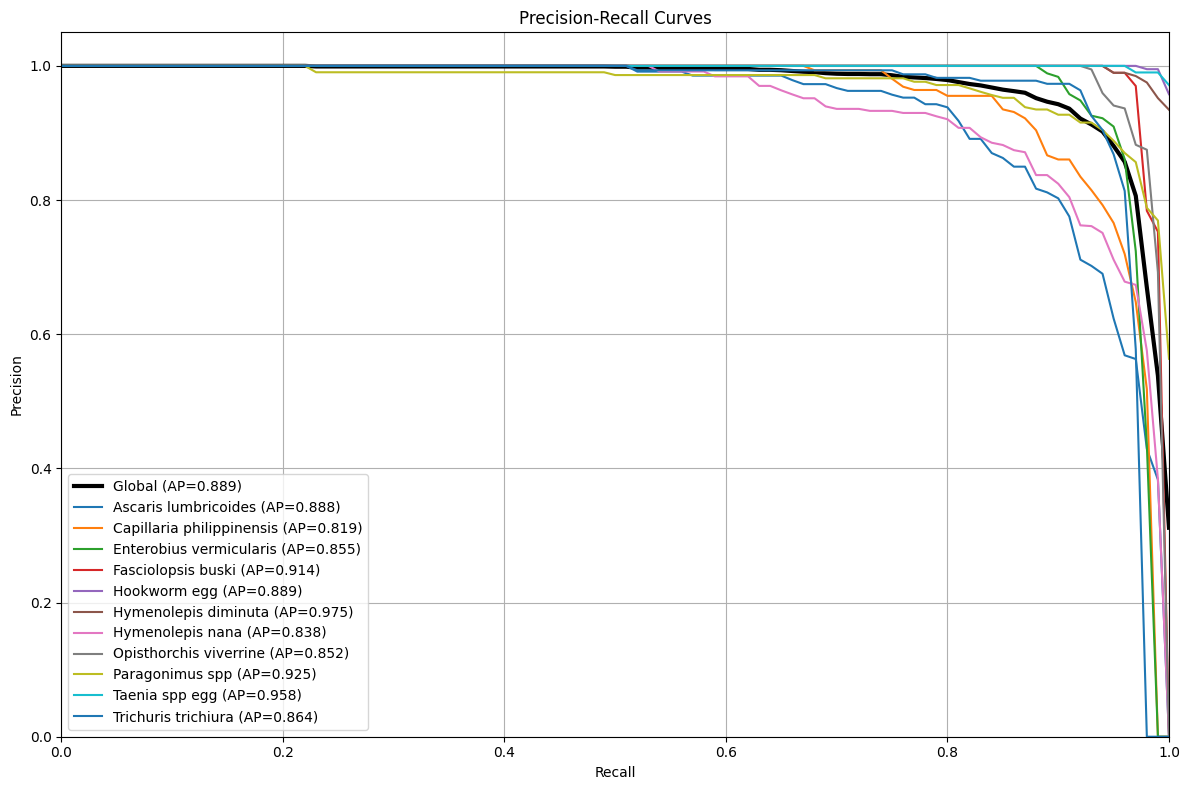

In [11]:
res.plot_pr_curves(output_path=None, show=True)

## 8. Confusion Matrix (if available)

Display and save the confusion matrix.

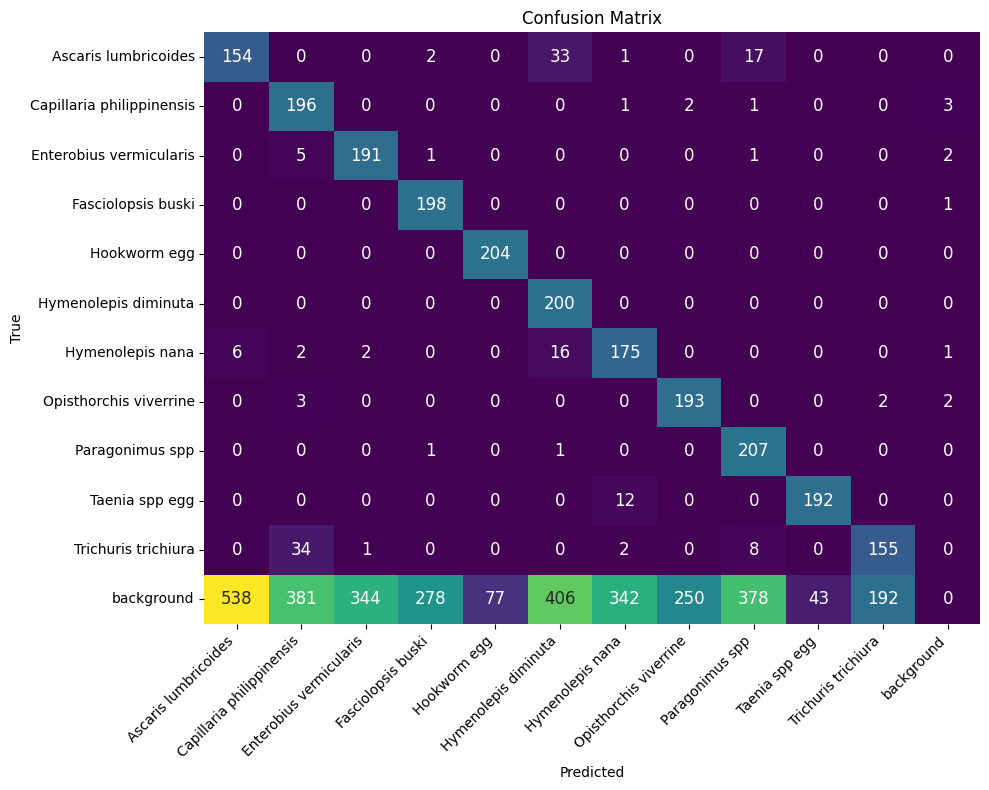

In [12]:
res.plot_confusion_matrix(show=True)

## 9. Conclusion

This covers the key features of `detmet`. Experiment with your own COCO JSON files!